# Тема 1. Моделирование геометрической вероятности
> Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.

Есть прямоугольный холст, на который случайным образом разбрызгивается краска. Смоделировать попадание брызг краски на треугольник, написанный на холсте.

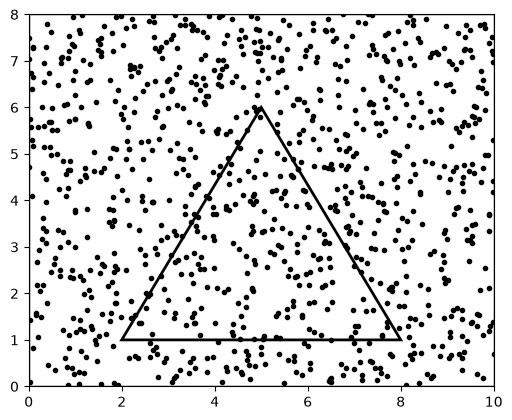

Всего капель: 1000
Попало в треугольник: 179
Экспериментальная вероятность: 0.1790
Теоретическая вероятность: 0.1875


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import numpy as np
from scipy.stats import uniform

def paint(n):
    W, H = 10, 8

    triangle = np.array([
        [2, 1],
        [8, 1],
        [5, 6]
    ])

    fig, ax = plt.subplots(figsize=(6, 5))

    ax.add_patch(Rectangle((0, 0), W, H, fill=False))

    ax.add_patch(Polygon(triangle, fill=False, linewidth=2))

    X = uniform.rvs(0, W, n)
    Y = uniform.rvs(0, H, n)

    inside = (
        (Y >= 1) &
        (Y <= 6) &
        (X >= 2 + 0.6 * (Y - 1)) &
        (X <= 8 - 0.6 * (Y - 1))
    )

    ax.scatter(X, Y, marker='.', c='black')

    p = inside.sum() / n

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal')

    plt.show()

    print(f'Всего капель: {n}')
    print(f'Попало в треугольник: {inside.sum()}')
    print(f'Экспериментальная вероятность: {p:.4f}')
    print(f'Теоретическая вероятность: {15 / 80:.4f}')


paint(1000)